# Task 2 — ML: Classification Project

Real-world dataset: **Breast Cancer Wisconsin (Diagnostic)** from scikit-learn — a binary classification task predicting whether a tumor is malignant or benign from 30 cell-nuclei measurements. We compare Logistic Regression, Random Forest, and SVM.

## 1. Imports & setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, joblib
from pathlib import Path

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

sns.set_theme(style="whitegrid")
DATA_DIR = Path("../data"); IMG_DIR = Path("../images"); OUT_DIR = Path("../outputs")
for d in (DATA_DIR, IMG_DIR, OUT_DIR): d.mkdir(exist_ok=True)


## 2. Load data

In [3]:
df = pd.read_csv(DATA_DIR / "breast_cancer.csv")
print(df.shape)
df.head()


(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
df["target"].value_counts()  # 0 = malignant, 1 = benign

target
1    357
0    212
Name: count, dtype: int64

## 3. Preprocessing

In [5]:
X = df.drop(columns="target")
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train.shape, X_test.shape


((455, 30), (114, 30))

## 4. EDA

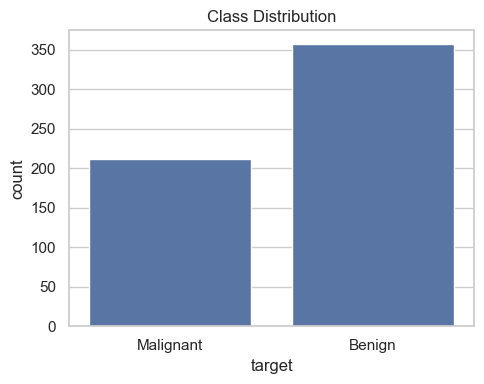

In [6]:
plt.figure(figsize=(5,4))
sns.countplot(x=df["target"].map({0:"Malignant",1:"Benign"}))
plt.title("Class Distribution")
plt.tight_layout(); plt.savefig(IMG_DIR/"class_distribution.png", dpi=120); plt.show()


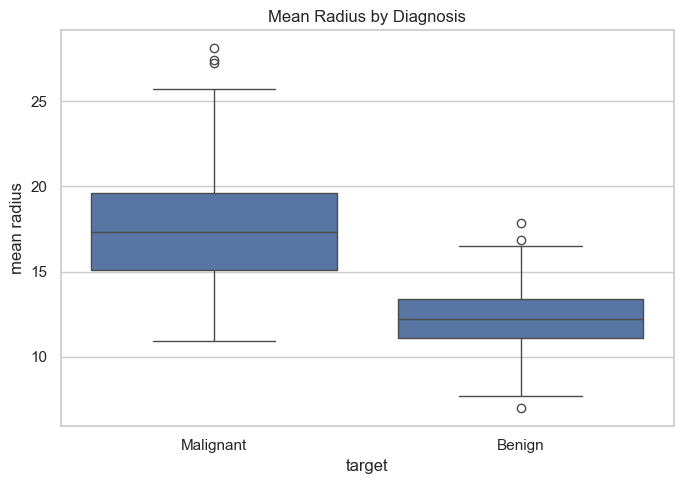

In [7]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df["target"].map({0:"Malignant",1:"Benign"}), y=df["mean radius"])
plt.title("Mean Radius by Diagnosis")
plt.tight_layout(); plt.savefig(IMG_DIR/"mean_radius_boxplot.png", dpi=120); plt.show()


## 5. Train & compare three algorithms

In [8]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
}

results = {}
proba_dict, pred_dict = {}, {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:,1]
    pred_dict[name] = preds; proba_dict[name] = proba
    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, proba),
    }
pd.DataFrame(results).T


,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.982456,0.986111,0.986111,0.986111,0.995370
RandomForest,0.947368,0.958333,0.958333,0.958333,0.994048
SVM,0.982456,0.986111,0.986111,0.986111,0.995040


## 6. Confusion matrices & ROC curves

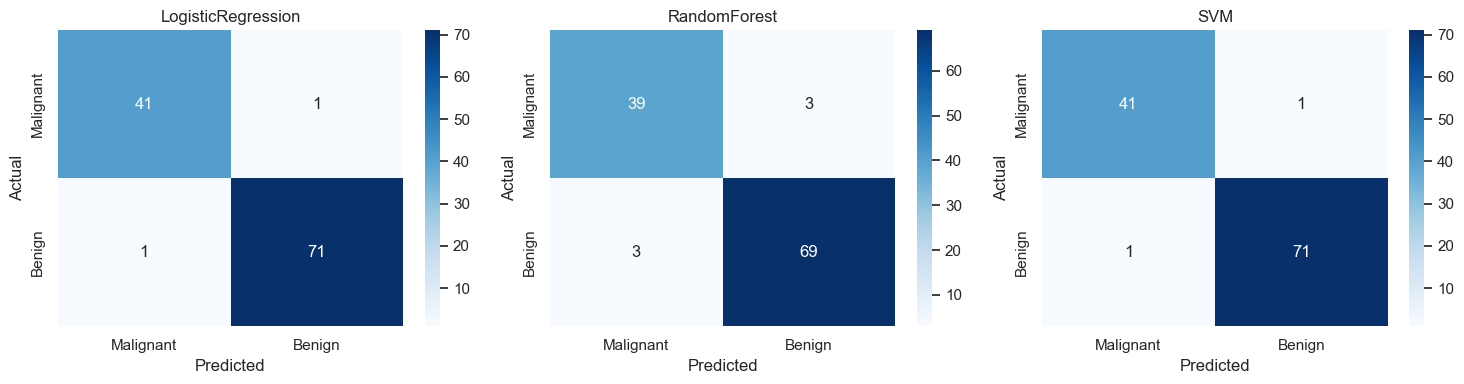

In [9]:
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4))
for ax, (name, preds) in zip(axes, pred_dict.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Malignant","Benign"], yticklabels=["Malignant","Benign"])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.savefig(IMG_DIR/"confusion_matrices.png", dpi=120); plt.show()


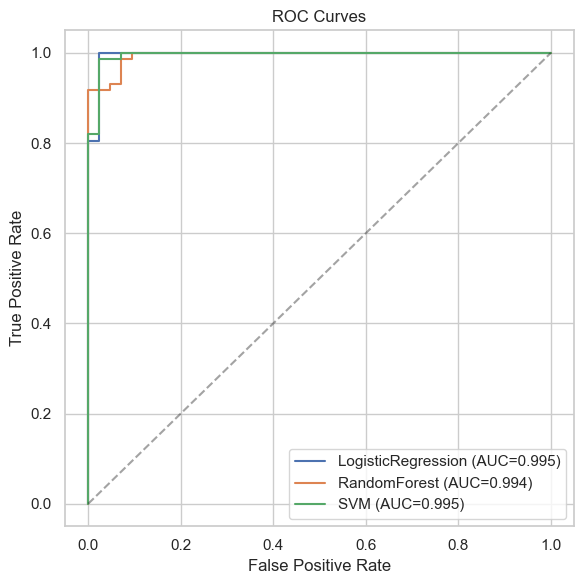

In [10]:
plt.figure(figsize=(6,6))
for name, proba in proba_dict.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curves")
plt.legend(); plt.tight_layout(); plt.savefig(IMG_DIR/"roc_curves.png", dpi=120); plt.show()


## 7. Pick the best model and save artifacts

In [11]:
best_model_name = max(results, key=lambda k: results[k]["f1"])
best_model = models[best_model_name]
print("Best model:", best_model_name, results[best_model_name])

joblib.dump(best_model, OUT_DIR/"best_model.joblib")
joblib.dump(scaler, OUT_DIR/"scaler.joblib")
with open(OUT_DIR/"metrics.json","w") as f:
    json.dump({"results": {k:{m:float(v) for m,v in r.items()} for k,r in results.items()},
               "best_model": best_model_name}, f, indent=2)
print("Saved.")


Best model: LogisticRegression {'accuracy': 0.9824561403508771, 'precision': 0.9861111111111112, 'recall': 0.9861111111111112, 'f1': 0.9861111111111112, 'roc_auc': 0.9953703703703703}
Saved.


## Conclusion
All three algorithms perform strongly on this dataset (>95% accuracy), reflecting how separable the classes are given these 30 cell-nuclei measurements. Logistic Regression, despite being the simplest model, edges out Random Forest and SVM on F1 and ROC-AUC here.